# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/intermim/` de los datos de entrenamiento
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

In [2]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

sns.set_theme(style="whitegrid")

train_path = "../data/interim/train_set.csv"
housing = pd.read_csv(train_path)

display(housing.head(5))

housing.info()

print(housing.isnull().sum())

display(housing.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
1,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
2,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
3,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
4,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        168
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity  

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16344.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,538.949094,1425.513929,499.990189,3.870428,206333.518653
std,2.000624,2.133294,12.585738,2185.287466,423.862079,1094.795467,382.865787,1.891936,115314.047529
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,787.000000,279.000000,2.562500,119200.000000
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500,179200.000000
75%,-118.010000,37.720000,37.000000,3154.000000,645.000000,1726.000000,603.000000,4.750000,263925.000000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100,500001.000000


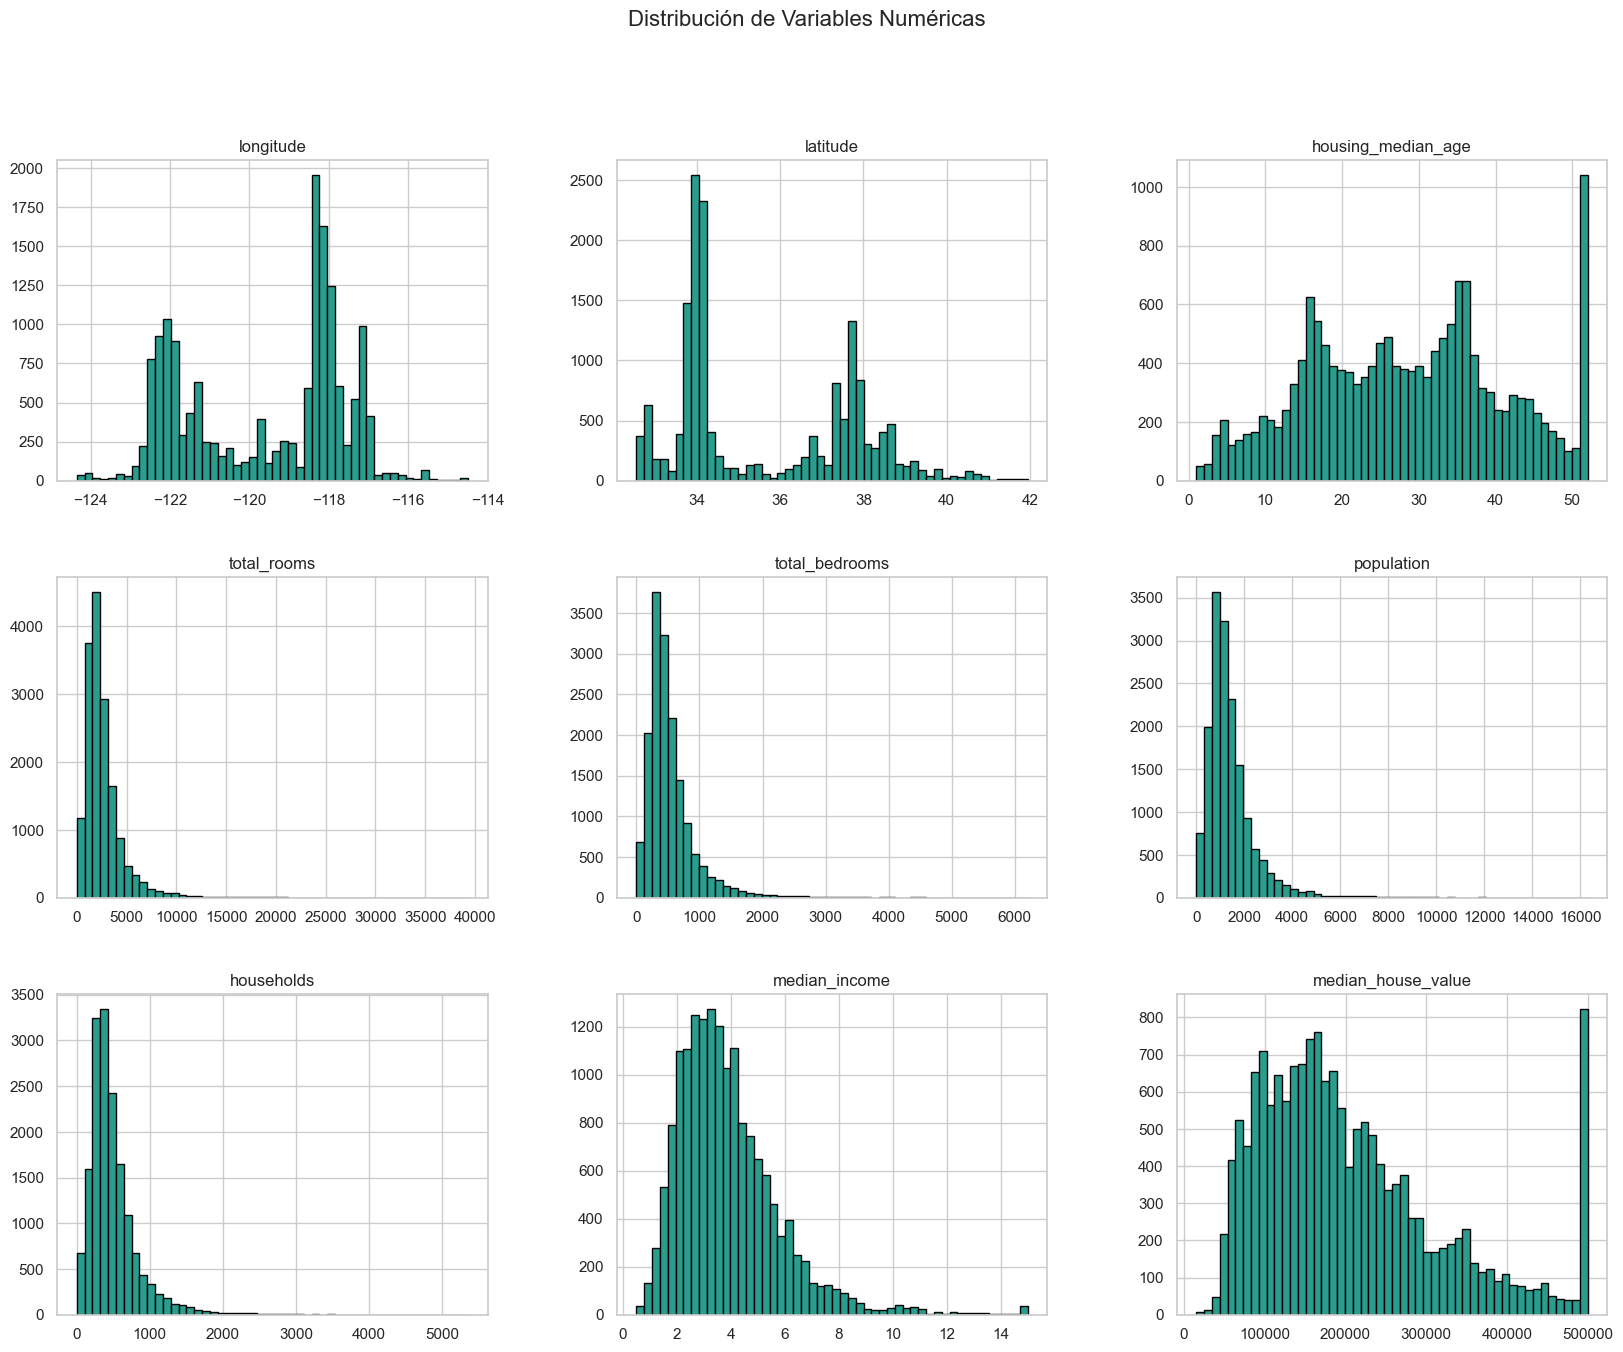

In [ ]:
# Histogramas de variables numéricas
# bins=50 define la cantidad de barras
housing.hist(bins=50, figsize=(20, 15), color='#2A9D8F', edgecolor='black')
plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.show()

In [ ]:
from pandas.plotting import scatter_matrix

# Matriz de correlación (solo variables numéricas)
# Excluimos 'ocean_proximity' porque es texto
housing_num = housing.select_dtypes(include=[np.number])
corr_matrix = housing_num.corr() 

print(corr_matrix["median_house_value"].sort_values(ascending=False))

Correlación de las variables frente al Precio de la Vivienda:
median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64


### 6. Conclusiones del Análisis Exploratorio (Hallazgos de Negocio)

Tras el análisis de los datos de entrenamiento, se identificaron los siguientes puntos críticos para la estrategia de modelado:

1. Calidad de Datos (Completitud): La variable total_bedrooms presenta valores nulos (faltantes).
2. Anomalías en la Precisión (Límites Artificiales): Se detectó mediante los histogramas que las variables median_house_value y `housing_median_age`, los precios de viviendas superiores a ~$500,000 están agrupados en un solo valor máximo. Si el modelo en producción necesita predecir valores precisos por encima de este límite, estos datos topados podrían introducir un sesgo de subestimación.
3. Factores Clave de Valorización (Correlación):  Existe una fuerte correlación lineal positiva 0.68 entre el median_income y median_house_value. 
